# <h1 style='background:#4682B4; border:2; border-radius: 10px; font-size:250%; font-weight: bold; color:black'><center>Water Quality</center></h1> 
 
<img src = "https://postila.ru/resize?w=&src=%2Fdata%2F9f%2F43%2F54%2F6e%2F9f43546e8c3e5942e33b07e16a02374c318975ef91e1d4f52ce6ac9b4ecdd16d.gif" width = 990 height = 810/>

Water quality is the chemical, physical and biological characteristics of water based on standards of use. They are most often used in relation to a set of standards, compliance with which, as a rule, is achieved by water treatment, can be assessed. The most common standards used to monitor and assess water quality reflect the health of ecosystems, the safety of human contact, and the health of drinking water. Water quality has a significant impact on water supply and often determines supply options.
Water quality parameters are determined by the intended use. Water quality work tends to focus on water that is treated for drinking water, industrial/domestic use, or restoration (environment/ecosystem, typically human health/aquatic life)

<a id='top'></a>
<div class="list-group" id="list-tab" role="tablist">
    
<h1 style='background:#4682B4; border:0; border-radius: 10px; color:black'><center> TABLE OF CONTENTS </center></h1>

### [**1. IMPORTING LIBRARIES AND LOADING DATA**](#title-one)

### [**2. DATA INFORMATION**](#title-two)

### [**3. EXPLORATORY DATA ANALYSIS**](#title-three)
    
### [**4. STATISTICAL TESTS**](#title-four) 
    
### [**5. MACHINE LEARNING**](#title-five)

### [**6. RECOMENDATIONS**](#title-six)
    
<a id="title-one"></a>
<h1 style='background:#4682B4; border:2; border-radius: 10px; color:black'><center>IMPORTING LIBRARIES AND LOADING DATA</center></h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import missingno as msno
from scipy import stats

In [2]:
train = pd.read_csv('../input/water-potability/water_potability.csv')

<a id="title-two"></a>
<h1 style='background:#4682B4; border:2; border-radius: 10px; color:black'><center>DATA INFORMATION</center></h1>

In [3]:
train

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


The dataset contains 3276 rows and 10 columns

1. pH value:
PH is an important parameter in evaluating the acid–base balance of water. It is also the indicator of acidic or alkaline condition of water status. WHO has recommended maximum permissible limit of pH from 6.5 to 8.5. The current investigation ranges were 6.52–6.83 which are in the range of WHO standards.

2. Hardness:
Hardness is mainly caused by calcium and magnesium salts. These salts are dissolved from geologic deposits through which water travels. The length of time water is in contact with hardness producing material helps determine how much hardness there is in raw water. Hardness was originally defined as the capacity of water to precipitate soap caused by Calcium and Magnesium.

3. Solids (Total dissolved solids - TDS):
Water has the ability to dissolve a wide range of inorganic and some organic minerals or salts such as potassium, calcium, sodium, bicarbonates, chlorides, magnesium, sulfates etc. These minerals produced un-wanted taste and diluted color in appearance of water. This is the important parameter for the use of water. The water with high TDS value indicates that water is highly mineralized. Desirable limit for TDS is 500 mg/l and maximum limit is 1000 mg/l which prescribed for drinking purpose.

4. Chloramines:
Chlorine and chloramine are the major disinfectants used in public water systems. Chloramines are most commonly formed when ammonia is added to chlorine to treat drinking water. Chlorine levels up to 4 milligrams per liter (mg/L or 4 parts per million (ppm)) are considered safe in drinking water.

5. Sulfate:
Sulfates are naturally occurring substances that are found in minerals, soil, and rocks. They are present in ambient air, groundwater, plants, and food. The principal commercial use of sulfate is in the chemical industry. Sulfate concentration in seawater is about 2,700 milligrams per liter (mg/L). It ranges from 3 to 30 mg/L in most freshwater supplies, although much higher concentrations (1000 mg/L) are found in some geographic locations.

6. Conductivity:
Pure water is not a good conductor of electric current rather’s a good insulator. Increase in ions concentration enhances the electrical conductivity of water. Generally, the amount of dissolved solids in water determines the electrical conductivity. Electrical conductivity (EC) actually measures the ionic process of a solution that enables it to transmit current. According to WHO standards, EC value should not exceeded 400 μS/cm.

7. Organic_carbon:
Total Organic Carbon (TOC) in source waters comes from decaying natural organic matter (NOM) as well as synthetic sources. TOC is a measure of the total amount of carbon in organic compounds in pure water. According to US EPA < 2 mg/L as TOC in treated / drinking water, and < 4 mg/Lit in source water which is use for treatment.

8. Trihalomethanes:
THMs are chemicals which may be found in water treated with chlorine. The concentration of THMs in drinking water varies according to the level of organic material in the water, the amount of chlorine required to treat the water, and the temperature of the water that is being treated. THM levels up to 80 ppm is considered safe in drinking water.

9. Turbidity:
The turbidity of water depends on the quantity of solid matter present in the suspended state. It is a measure of light emitting properties of water and the test is used to indicate the quality of waste discharge with respect to colloidal matter. The mean turbidity value obtained for Wondo Genet Campus (0.98 NTU) is lower than the WHO recommended value of 5.00 NTU.

10. Potability:
Indicates if water is safe for human consumption where 1 means Potable and 0 means Not potable.

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


All features except Potability are fractional.

Let's look at the statistics of the dataset

In [5]:
train.describe().style.background_gradient(cmap = "Blues")

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


There are outliers in the data. We can delete no more than 1-2% of the data, i.e. 30-60 rows.

Let's check our dataset for duplicates.

In [6]:
train.duplicated().sum()

0

It's ok.

<a id="title-three"></a>
<h1 style='background:#4682B4; border:2; border-radius: 10px; color:black'><center>EXPLORATORY DATA ANALYSIS</center></h1>

Let's look at the missing values in the dataset.

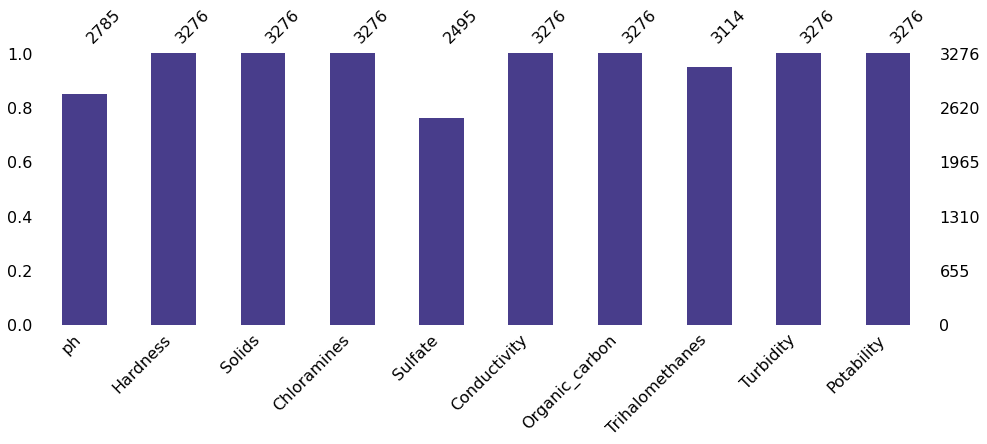

In [7]:
msno.bar(train, figsize = (16,5),color = "#483D8B")
plt.show()

In the future, it is proposed to restore the values of sulfate, ph, trihalomethanes using KNNImputer.

Check the dataset for categorical features.

In [8]:
for column_name in train.columns:
    unique_values = len(train[column_name].unique())
    print("Feature '{column_name}' has '{unique_values}' unique values".format(column_name = column_name,
                                                                                         unique_values=unique_values))

Feature 'ph' has '2786' unique values
Feature 'Hardness' has '3276' unique values
Feature 'Solids' has '3276' unique values
Feature 'Chloramines' has '3276' unique values
Feature 'Sulfate' has '2496' unique values
Feature 'Conductivity' has '3276' unique values
Feature 'Organic_carbon' has '3276' unique values
Feature 'Trihalomethanes' has '3115' unique values
Feature 'Turbidity' has '3276' unique values
Feature 'Potability' has '2' unique values


Great, only one feature is categorical, the rest are continuous numeric. Let's do a quick analysis of continuous features.

In [9]:
train.columns

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability'],
      dtype='object')

In [10]:
numeric_features=['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Text(0.5, 0.98, 'Visualizing continuous columns (train dataset)')

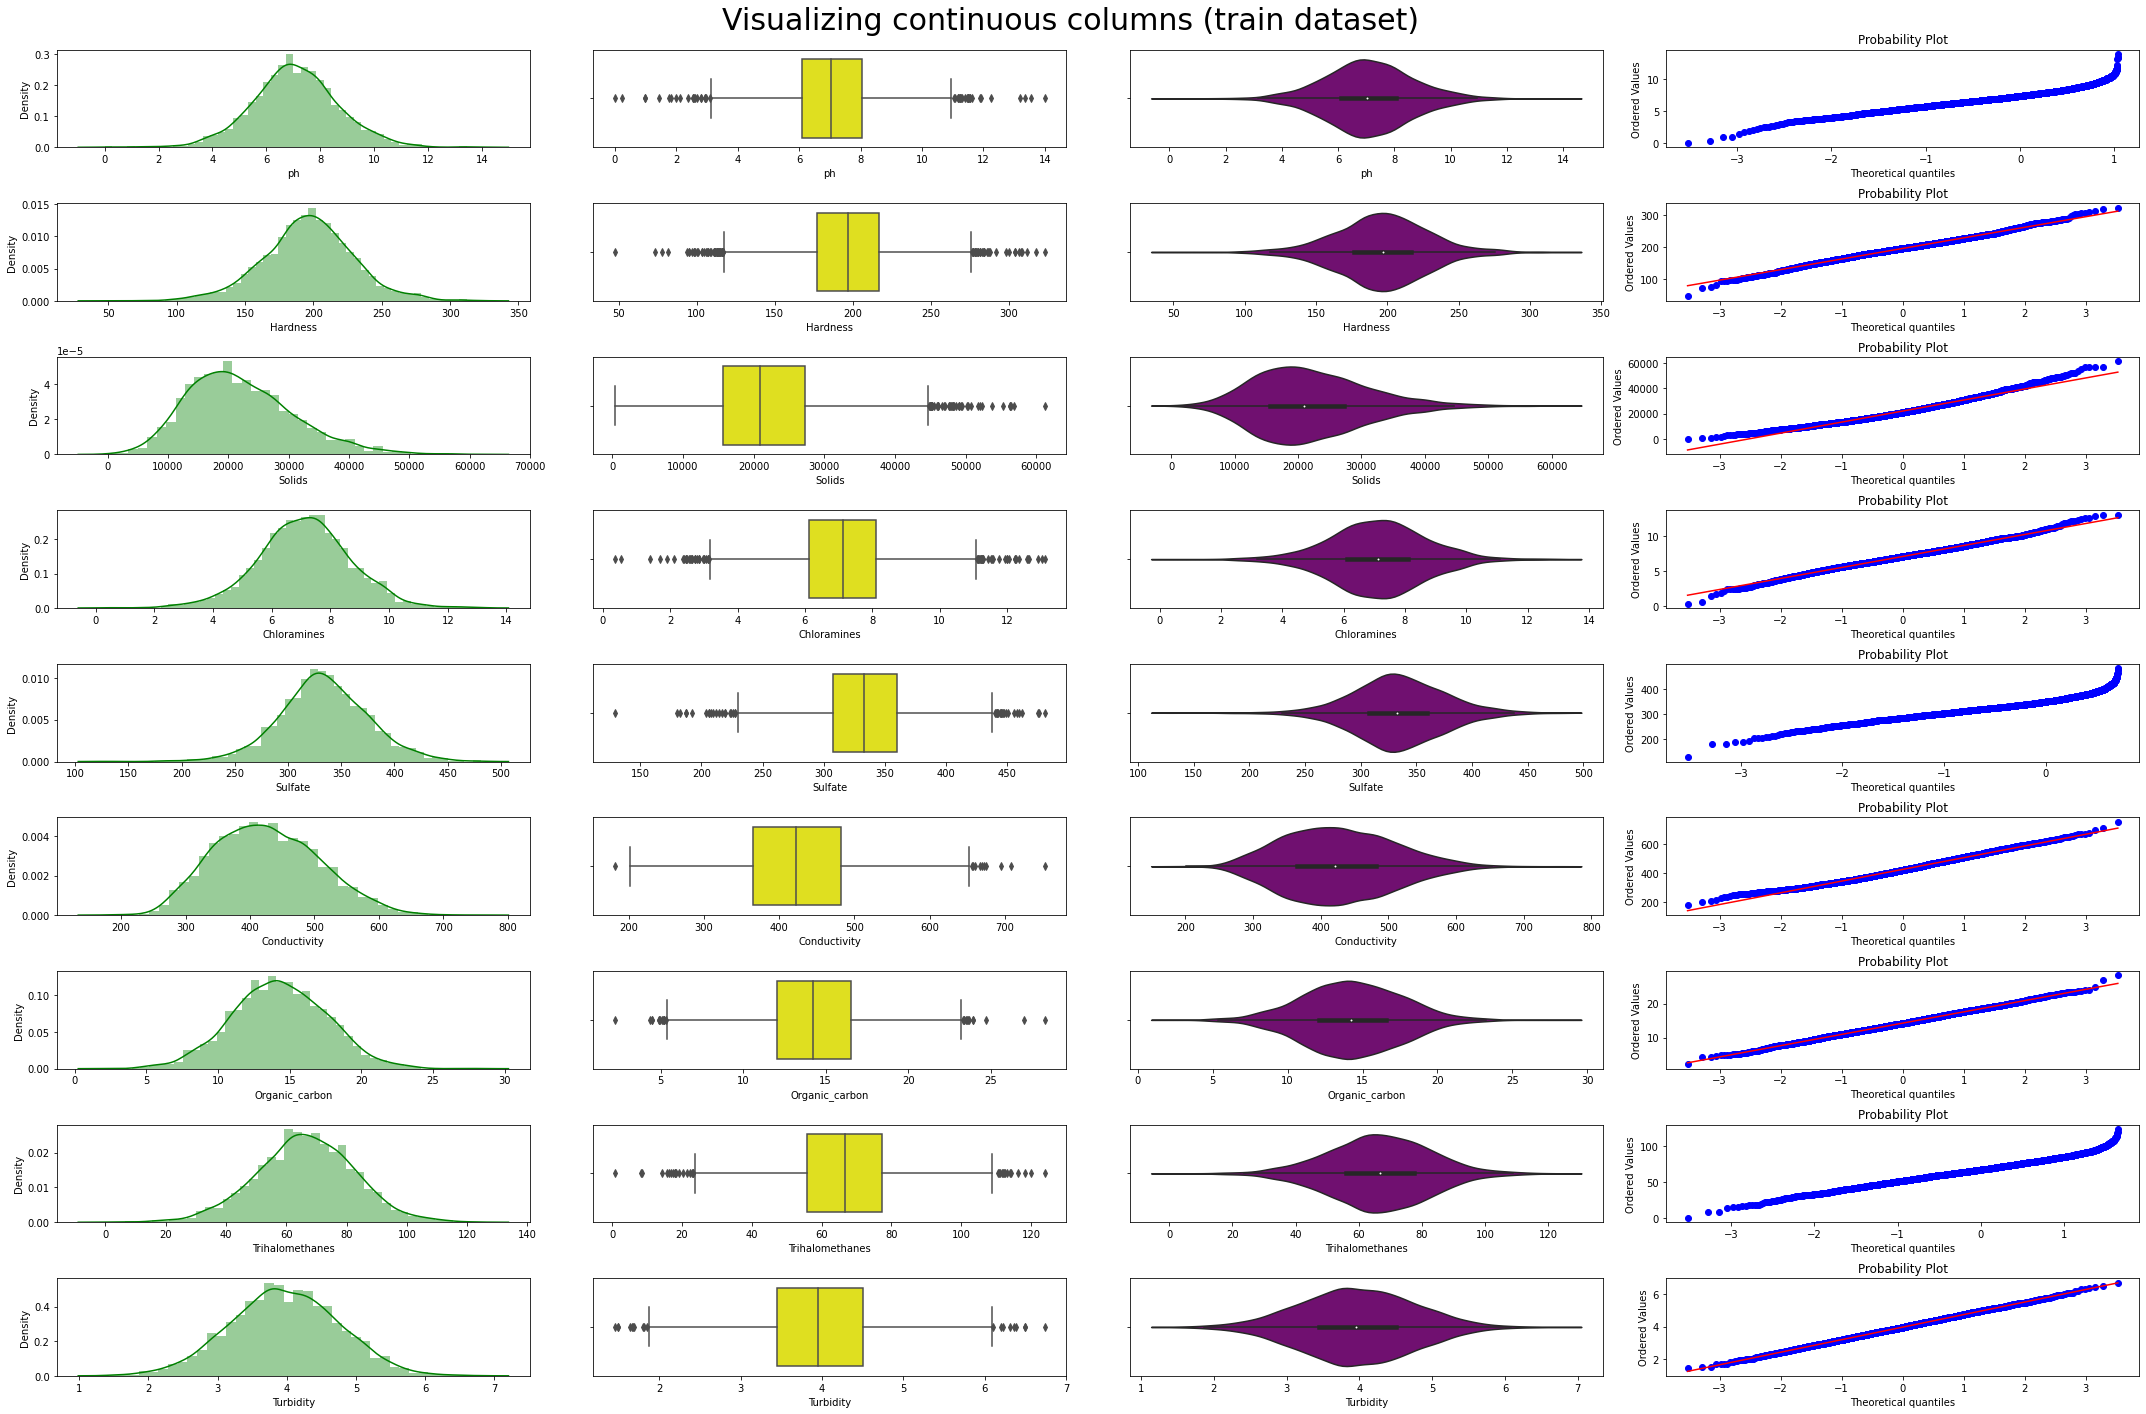

In [11]:
import warnings
warnings.filterwarnings('ignore')
fig,ax = plt.subplots(len(numeric_features),4,figsize=(30,20))
for index,i in enumerate(numeric_features):
    sns.distplot(train[i],ax=ax[index,0],color='green')
    sns.boxplot(train[i],ax=ax[index,1],color='yellow')
    sns.violinplot(train[i],ax=ax[index,2],color='purple')
    stats.probplot(train[i],plot=ax[index,3])
    
fig.tight_layout()
fig.subplots_adjust(top=0.95)
plt.suptitle("Visualizing continuous columns (train dataset)",fontsize=30)

After analyzing these graphs, the following hypotheses can be made:
* Most features are distributed according to the normal distribution law.
* There are minor outliers for some features.

Let's look at the distribution of the target feature.

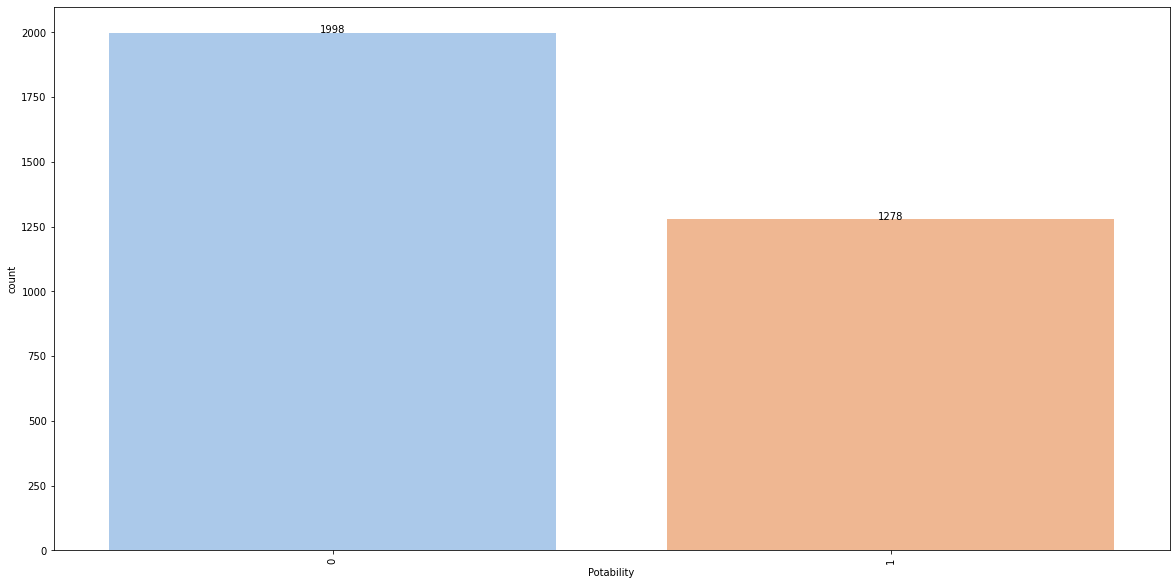

In [12]:
fig, ax1 = plt.subplots(figsize=(20,10))
graph = sns.countplot(ax=ax1,x = 'Potability' , data = train,palette='pastel')
graph.set_xticklabels(graph.get_xticklabels(),rotation=90)
for p in graph.patches:
    height = p.get_height()
    graph.text(p.get_x()+p.get_width()/2., height + 0.1,height ,ha="center")

There is a clear class imbalance.

Let's fill in the gaps of information, after which we will begin to conduct statistical tests.

In [13]:
train.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [14]:
from sklearn.impute import KNNImputer

In [15]:
imputer = KNNImputer(n_neighbors=10, weights="uniform")

In [16]:
l=imputer.fit_transform(train)

In [17]:
train1=pd.DataFrame(l,columns=train.columns)

In [18]:
train1

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.417308,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0.0
1,3.716080,129.422921,18630.057858,6.635246,341.794864,592.885359,15.180013,56.329076,4.500656,0.0
2,8.099124,224.236259,19909.541732,9.275884,329.237272,418.606213,16.868637,66.420093,3.055934,0.0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0.0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0.0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1.0
3272,7.808856,193.553212,17329.802160,8.061362,341.343026,392.449580,19.903225,62.554876,2.798243,1.0
3273,9.419510,175.762646,33155.578218,7.350233,335.228216,432.044783,11.039070,69.845400,3.298875,1.0
3274,5.126763,230.603758,11983.869376,6.303357,336.711411,402.883113,11.168946,77.488213,4.708658,1.0


In [19]:
train1.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

The contents of the gaps are filled with the k-nearest neighbors method.

<a id="title-four"></a>
<h1 style='background:#4682B4; border:2; border-radius: 10px; color:black'><center>STATISTICAL TESTS</center></h1>

Let's check whether the signs are normally distributed and, based on this, we will conclude what further test is needed.

In [20]:
# Shapiro-Wilk Test
from scipy.stats import shapiro
# normality test
for feature in numeric_features:
	stat, p = shapiro(train1[feature])
	print('Statistics=%.3f, p=%.3f' % (stat, p))
	# interpret
	alpha = 0.05
	if p > alpha:
		print(f'Sample looks Gaussian with {feature} (fail to reject H0)')
	else:
		print(f'Sample does not look Gaussian with {feature} (reject H0)')

Statistics=0.989, p=0.000
Sample does not look Gaussian with ph (reject H0)
Statistics=0.996, p=0.000
Sample does not look Gaussian with Hardness (reject H0)
Statistics=0.978, p=0.000
Sample does not look Gaussian with Solids (reject H0)
Statistics=0.997, p=0.000
Sample does not look Gaussian with Chloramines (reject H0)
Statistics=0.984, p=0.000
Sample does not look Gaussian with Sulfate (reject H0)
Statistics=0.993, p=0.000
Sample does not look Gaussian with Conductivity (reject H0)
Statistics=1.000, p=0.620
Sample looks Gaussian with Organic_carbon (fail to reject H0)
Statistics=0.998, p=0.000
Sample does not look Gaussian with Trihalomethanes (reject H0)
Statistics=1.000, p=0.931
Sample looks Gaussian with Turbidity (fail to reject H0)


ТSince most of the features are not distributed according to the normal distribution law, we will use the Mann-Whitney Y-test.

In [21]:
from scipy.stats import mannwhitneyu
for feature in numeric_features:
    stat, p = mannwhitneyu(train1['Potability'], train1[feature])
    print('Statistics=%.3f, p=%.3f' % (stat, p))
    alpha = 0.05
    if p > alpha:
		    print('There are no significant differences (fail to reject H0)')
    else:
		    print('The sample distributions are not equal (reject H0)')

Statistics=6111.000, p=0.000
The sample distributions are not equal (reject H0)
Statistics=0.000, p=0.000
The sample distributions are not equal (reject H0)
Statistics=0.000, p=0.000
The sample distributions are not equal (reject H0)
Statistics=2556.000, p=0.000
The sample distributions are not equal (reject H0)
Statistics=0.000, p=0.000
The sample distributions are not equal (reject H0)
Statistics=0.000, p=0.000
The sample distributions are not equal (reject H0)
Statistics=0.000, p=0.000
The sample distributions are not equal (reject H0)
Statistics=1278.000, p=0.000
The sample distributions are not equal (reject H0)
Statistics=0.000, p=0.000
The sample distributions are not equal (reject H0)


Great, the final model will include all the variables.

Let's build a correlation matrix in order to check if there are mutually correlated continuous features.

In [22]:
correlation = train1.corr()
print(correlation['Potability'].sort_values(ascending = False),'\n')

Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.008692
Turbidity          0.001581
ph                -0.002354
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.017988
Organic_carbon    -0.030001
Name: Potability, dtype: float64 



Index(['Potability', 'Solids', 'Chloramines', 'Trihalomethanes', 'Turbidity',
       'ph', 'Conductivity', 'Hardness', 'Sulfate', 'Organic_carbon'],
      dtype='object')


<AxesSubplot:>

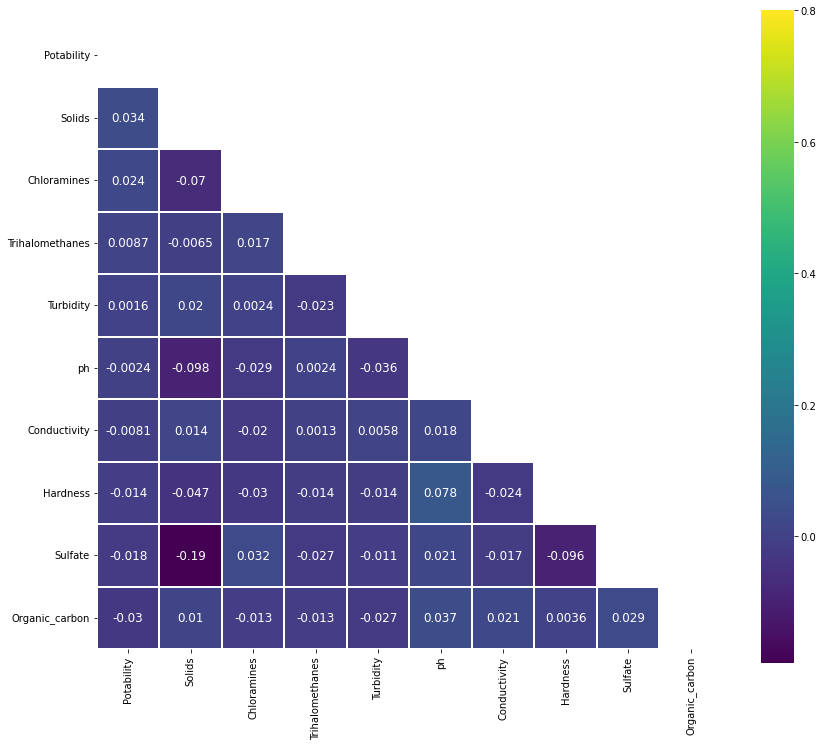

In [23]:
k= 18
cols = correlation.nlargest(k,'Potability')['Potability'].index
print(cols)
cm = np.corrcoef(train1[cols].values.T)
mask = np.triu(np.ones_like(train1.corr()))
f , ax = plt.subplots(figsize = (14,12))
sns.heatmap(cm,mask=mask, vmax=.8, linewidths=0.01,square=True,annot=True,cmap='viridis',
            linecolor="white",xticklabels = cols.values ,annot_kws = {'size':12},yticklabels = cols.values)

Great, there are no mutually correlated signs, outliers can be removed, and class imbalance can also be eliminated.

In [24]:
from sklearn.neighbors import LocalOutlierFactor

In [25]:
clf = LocalOutlierFactor(n_neighbors=5, contamination='auto')
y_pred = clf.fit_predict(train1) 

In [26]:
train1['Out']=y_pred

In [27]:
Out=train[train1['Out']!=1]

In [28]:
Out.shape

(54, 10)

In [29]:
train2=train1[train1['Out']==1]

In [30]:
train2=train2.drop('Out',axis=1)

Let's look again at the distribution of the target variable.

There is a clear class imbalance. It is proposed to create artificial duplicates to eliminate this effect.

In [31]:
from imblearn.over_sampling import SMOTE 

In [32]:
oversample = SMOTE()
features, labels=  oversample.fit_resample(train2.drop(["Potability"],axis=1),train2["Potability"])

To increase the accuracy of forecasting, I propose to normalize the data within [0,1]

In [33]:
from sklearn.preprocessing import MinMaxScaler

In [34]:
scaler = MinMaxScaler()
names = features.columns
d = scaler.fit_transform(features)

scaled_df = pd.DataFrame(d, columns=names)
scaled_df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.529808,0.526368,0.362007,0.543891,0.680385,0.762704,0.313402,0.699753,0.286091
1,0.265434,0.224053,0.323786,0.491839,0.604478,0.824275,0.497319,0.450999,0.576793
2,0.578509,0.603866,0.346413,0.698543,0.568806,0.448774,0.562017,0.532866,0.303637
3,0.594055,0.564356,0.383707,0.603314,0.647347,0.329540,0.622089,0.808065,0.601015
4,0.649445,0.431072,0.312272,0.484900,0.514545,0.405261,0.358555,0.253606,0.496327


Let's proceed to the selection of the optimal machine learning algorithm. To do this, we divide the data into training and test sets, and also create simple pipelines of classification models.

<a id="title-five"></a>
<h1 style='background:#4682B4; border:2; border-radius: 10px; color:black'><center>MACHINE LEARNING</center></h1>

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
import xgboost as xgb

from sklearn.metrics import precision_score,recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix,accuracy_score, classification_report

In [36]:
X_train, X_test, y_train, y_test=train_test_split(scaled_df,labels,test_size=0.33,random_state=42)

In [37]:
models = [RandomForestClassifier(), KNeighborsClassifier(), SVC(), LogisticRegression(),xgb.XGBClassifier()]
scores = dict()

for m in models:
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)

    print(f'model: {str(m)}')
    print(classification_report(y_test,y_pred, zero_division=1))
    print('-'*30, '\n')

model: RandomForestClassifier()
              precision    recall  f1-score   support

         0.0       0.67      0.72      0.69       636
         1.0       0.71      0.66      0.68       664

    accuracy                           0.69      1300
   macro avg       0.69      0.69      0.69      1300
weighted avg       0.69      0.69      0.69      1300

------------------------------ 

model: KNeighborsClassifier()
              precision    recall  f1-score   support

         0.0       0.63      0.57      0.60       636
         1.0       0.62      0.67      0.65       664

    accuracy                           0.62      1300
   macro avg       0.62      0.62      0.62      1300
weighted avg       0.62      0.62      0.62      1300

------------------------------ 

model: SVC()
              precision    recall  f1-score   support

         0.0       0.66      0.64      0.65       636
         1.0       0.66      0.68      0.67       664

    accuracy                           0.

The RFC does a better job of defining a class. Let's find the optimal hyperparameters of the model using the optuna library. Подбор параметров будем осуществлять на кроссвалидации.

In [38]:
!pip install optuna

In [39]:
import optuna 
from optuna import Trial, visualization
from optuna.samplers import TPESampler
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [40]:
def objective(trial: Trial,X,y) -> float:
    
    param = {
            'n_estimators' : trial.suggest_int("n_estimators",100,1500),
            'max_features' : trial.suggest_categorical("max_features",["auto","sqrt"]),
            'max_depth' : trial.suggest_int("max_depth",5,80,log = True),
            'min_samples_split' : trial.suggest_int("min_samples_split",2,15),
            'min_samples_leaf' : trial.suggest_int("min_samples_leaf",1,9),
            'bootstrap' : trial.suggest_categorical("bootstrap",[True,False])
            }
    
    model = RandomForestClassifier(**param)
    
    return cross_val_score(model, X, y, cv=5).mean()

In [41]:
study = optuna.create_study(direction='maximize',sampler=TPESampler())
study.optimize(lambda trial : objective(trial,X_train,y_train),n_trials= 20)

[I 2022-09-09 03:49:48,797] A new study created in memory with name: no-name-461eb6b2-e6b1-4cc2-a315-428050821033
[I 2022-09-09 03:50:13,725] Trial 0 finished with value: 0.5822616583290208 and parameters: {'n_estimators': 881, 'max_features': 'auto', 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 7, 'bootstrap': False}. Best is trial 0 with value: 0.5822616583290208.
[I 2022-09-09 03:50:30,592] Trial 1 finished with value: 0.6402586107756886 and parameters: {'n_estimators': 462, 'max_features': 'sqrt', 'max_depth': 16, 'min_samples_split': 14, 'min_samples_leaf': 8, 'bootstrap': True}. Best is trial 1 with value: 0.6402586107756886.
[I 2022-09-09 03:51:08,259] Trial 2 finished with value: 0.64898366971422 and parameters: {'n_estimators': 986, 'max_features': 'auto', 'max_depth': 73, 'min_samples_split': 13, 'min_samples_leaf': 4, 'bootstrap': True}. Best is trial 2 with value: 0.64898366971422.
[I 2022-09-09 03:52:02,087] Trial 3 finished with value: 0.6466951296647692 a

In [42]:
from optuna import visualization
print('Best trial: CV_score= {},\nparams {}'.format(study.best_trial.value,study.best_trial.params))
hist = study.trials_dataframe()
hist.head()

Best trial: CV_score= 0.670208009890173,
params {'n_estimators': 359, 'max_features': 'sqrt', 'max_depth': 48, 'min_samples_split': 4, 'min_samples_leaf': 2, 'bootstrap': True}


,number,value,datetime_start,datetime_complete,duration,params_bootstrap,params_max_depth,params_max_features,params_min_samples_leaf,params_min_samples_split,params_n_estimators,state
0,0,0.582262,2022-09-09 03:49:48.798921,2022-09-09 03:50:13.724912,0 days 00:00:24.925991,False,5,auto,7,13,881,COMPLETE
1,1,0.640259,2022-09-09 03:50:13.726808,2022-09-09 03:50:30.591833,0 days 00:00:16.865025,True,16,sqrt,8,14,462,COMPLETE
2,2,0.648984,2022-09-09 03:50:30.593879,2022-09-09 03:51:08.258654,0 days 00:00:37.664775,True,73,auto,4,13,986,COMPLETE
3,3,0.646695,2022-09-09 03:51:08.260677,2022-09-09 03:52:02.086484,0 days 00:00:53.825807,False,28,auto,8,2,967,COMPLETE
4,4,0.656553,2022-09-09 03:52:02.088435,2022-09-09 03:53:00.116294,0 days 00:00:58.027859,False,70,auto,4,11,961,COMPLETE


In [43]:
optuna.visualization.plot_slice(study)

In [44]:
optuna.visualization.plot_optimization_history(study)

In [45]:
optuna.visualization.plot_parallel_coordinate(study)

In [46]:
optuna.visualization.plot_param_importances(study)

In [47]:
Best_trial = study.best_trial.params

In [48]:
best_clf2=RandomForestClassifier(**Best_trial)
best_clf2.fit(X_train, y_train)

RandomForestClassifier(max_depth=48, max_features='sqrt', min_samples_leaf=2,
                       min_samples_split=4, n_estimators=359)

We choose the best model for cross-validation with the given parameters.

A simple baseline turned out to be better, but when using the optuna, the evaluation was carried out on cross-validation, so this model will definitely not have retraining :))

Let's build an error matrix

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

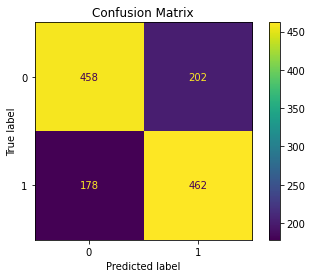

In [50]:
cm = confusion_matrix(best_clf2.predict(X_test),y_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["0","1"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

Let's analyze the important features.

In [51]:
feature_importances=best_clf2.feature_importances_
feature_importances_df=pd.DataFrame({'features':list(X_train), 'feature_importances':feature_importances})
feature_importances_df=pd.DataFrame({'features':list(X_train), 'feature_importances':feature_importances})
feature_importances_df.sort_values('feature_importances',ascending=False)

,features,feature_importances
0,ph,0.137891
4,Sulfate,0.125809
2,Solids,0.118570
3,Chloramines,0.115210
1,Hardness,0.110647
6,Organic_carbon,0.100476
5,Conductivity,0.100368
7,Trihalomethanes,0.096037
8,Turbidity,0.094992


<a id="title-six"></a>
<h1 style='background:#4682B4; border:2; border-radius: 10px; color:black'><center>RECOMENDATIONS</center></h1>


* Settling. It's probably impossible to find something easier. It helps a lot to remove excess chlorine from the water, although not completely. Water must be poured into a vessel without a lid, left in it for 7 hours. First, volatile gases will evaporate from such water, then salts of heavy metals will precipitate. And now, after settling, you can pour about ¾ already into a new vessel without shaking. The rest is just poured out.
* Boiling. Also a characteristic cleaning method. To make the water purified, it is boiled over low heat for an hour. Only before this, the water must be defended, because if chlorine is present in the water, when boiled, it will become a very harmful carcinogen. And the boiling method cannot be the main one, since, alas, it increases the concentration of salts of heavy metals.
* Acid cleaning. For example, half a gram of ascorbic acid per 5 liters of water - that's the whole recipe for high-quality cleaning. The acid will work for about an hour. But this method is also often criticized, therefore, it may not be worth adding it to the list of the most used ones.
* Activated carbon. This component is often used as a sorbent in industrial filters. Charcoal tablets can also be used at home. Several pieces should be wrapped in gauze, put on the bottom of the container with liquid. It will take about half a day to clean up. Coal perfectly absorbs chlorine, helps to restore the neutrality of water with respect to odors.
* Apply filters. Ready-made industrial filters are, of course, the most comfortable option. Even ordinary meshes, which easily trap foreign particles, are already something. Very attractive filters with a nozzle on the faucet. Some of them are such models that pass ordinary water through the tap, there are those that direct the flow into the filter itself, and in this way they purify drinking water. Pitcher filters are also convenient, but their volume, unlike the previous ones, is limited. True, they are mobile, and this is their forte.
